In [71]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# Configuración de rutas

In [72]:
# Directorio raíz del proyecto
project_root = Path.cwd().parent

input_file = (
    project_root
    / "data"
    / "raw"
    / "dataset_dna_demanda_b1.csv"
)

output_dir = (
    project_root
    / "reports"
    / "figures"
)

output_dir.mkdir(parents=True, exist_ok=True)


# Cargar dataset

In [73]:
df = pd.read_csv(input_file)

print("=" * 60)
print("DATASET CARGADO")
print("=" * 60)
print(f"Archivo: {input_file}")


DATASET CARGADO
Archivo: c:\Users\LENOVO\Desktop\dna_project\data\raw\dataset_dna_demanda_b1.csv


# Cantidad de filas y columnas

In [74]:
df.shape

(3234, 15)

# Vista general del dataset

In [75]:
df.head()

,gestion,mes,id_tipologia,tipologia,nivel_complejidad,hombres,mujeres,ninos_ninas,adolescentes,total_atenciones,target_demanda,atenciones_lag_1,atenciones_lag_2,atenciones_lag_3,promedio_movil_3m
0,2023,2,1,Asistencia Familiar,Baja,0,0,0,0,0,0,0,0,0,0.00
1,2023,3,1,Asistencia Familiar,Baja,0,1,0,1,1,1,0,0,0,0.00
2,2023,4,1,Asistencia Familiar,Baja,0,0,0,0,0,0,1,0,0,0.50
3,2023,5,1,Asistencia Familiar,Baja,0,0,0,0,0,0,0,1,0,0.33
4,2023,6,1,Asistencia Familiar,Baja,0,0,0,0,0,0,0,0,1,0.33


# Información del dataset

In [76]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 3234 entries, 0 to 3233
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   gestion            3234 non-null   int64  
 1   mes                3234 non-null   int64  
 2   id_tipologia       3234 non-null   int64  
 3   tipologia          3234 non-null   str    
 4   nivel_complejidad  3234 non-null   str    
 5   hombres            3234 non-null   int64  
 6   mujeres            3234 non-null   int64  
 7   ninos_ninas        3234 non-null   int64  
 8   adolescentes       3234 non-null   int64  
 9   total_atenciones   3234 non-null   int64  
 10  target_demanda     3234 non-null   int64  
 11  atenciones_lag_1   3234 non-null   int64  
 12  atenciones_lag_2   3234 non-null   int64  
 13  atenciones_lag_3   3234 non-null   int64  
 14  promedio_movil_3m  3234 non-null   float64
dtypes: float64(1), int64(12), str(2)
memory usage: 479.8 KB


# Estadísticas descriptivas

In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
gestion,3234.0,2024.000000,0.816623,2023.0,2023.0,2024.0,2025.0,2025.0
mes,3234.0,7.000000,3.162767,2.0,4.0,7.0,10.0,12.0
id_tipologia,3234.0,49.500000,28.293065,1.0,25.0,49.5,74.0,98.0
hombres,3234.0,0.035869,0.265468,0.0,0.0,0.0,0.0,6.0
mujeres,3234.0,0.057823,0.368152,0.0,0.0,0.0,0.0,6.0
ninos_ninas,3234.0,0.047310,0.340012,0.0,0.0,0.0,0.0,5.0
adolescentes,3234.0,0.045764,0.316192,0.0,0.0,0.0,0.0,6.0
total_atenciones,3234.0,0.093692,0.549051,0.0,0.0,0.0,0.0,10.0
target_demanda,3234.0,0.047619,0.212992,0.0,0.0,0.0,0.0,1.0
atenciones_lag_1,3234.0,0.091837,0.545976,0.0,0.0,0.0,0.0,10.0


# Convertir variables categóricas

In [78]:
columnas = ["nivel_complejidad", "tipologia"]

for columna in columnas:
    df[columna] = df[columna].astype("category")

df.dtypes


gestion                 int64
mes                     int64
id_tipologia            int64
tipologia            category
nivel_complejidad    category
hombres                 int64
mujeres                 int64
ninos_ninas             int64
adolescentes            int64
total_atenciones        int64
target_demanda          int64
atenciones_lag_1        int64
atenciones_lag_2        int64
atenciones_lag_3        int64
promedio_movil_3m     float64
dtype: object

# Valores faltantes

In [79]:
df.isnull().sum()


gestion              0
mes                  0
id_tipologia         0
tipologia            0
nivel_complejidad    0
hombres              0
mujeres              0
ninos_ninas          0
adolescentes         0
total_atenciones     0
target_demanda       0
atenciones_lag_1     0
atenciones_lag_2     0
atenciones_lag_3     0
promedio_movil_3m    0
dtype: int64

# Registros duplicados

In [80]:
df.duplicated().sum()


np.int64(0)

# Cantidad de ceros

In [81]:
(df == 0).sum()


gestion                 0
mes                     0
id_tipologia            0
tipologia               0
nivel_complejidad       0
hombres              3154
mujeres              3121
ninos_ninas          3146
adolescentes         3139
total_atenciones     3080
target_demanda       3080
atenciones_lag_1     3084
atenciones_lag_2     3089
atenciones_lag_3     3096
promedio_movil_3m    2949
dtype: int64

# Análisis del target

In [82]:
total_obs = len(df)
positivos = (df["target_demanda"] == 1).sum()
pct_pos = (positivos / total_obs) * 100
activos_df = df[df["target_demanda"] == 1]
exactamente_1 = (activos_df["total_atenciones"] == 1).sum()
pct_exactamente_1 = (exactamente_1 / positivos) * 100 if positivos > 0 else 0
print(f"Total observaciones (Tipología-Mes): {total_obs}")
print(f"Meses con Demanda Inactiva (0): {total_obs - positivos} ({(100 - pct_pos):.2f}%)")
print(f"Meses con Demanda Activa (1): {positivos} ({pct_pos:.2f}%)")
print(f"\nHALLAZGO CLAVE DEL EDA:")
print(f" De los {positivos} meses activos, {exactamente_1} registros ({pct_exactamente_1:.2f}%) tienen exactamente 1 sola atención.")
print(f"\nDECISIÓN METODOLÓGICA DERIVADA:")
print(" Este comportamiento empírico demuestra que el target representa la Ocurrencia o")
print(" Activación de Demanda Operativa (Presencia/Ausencia), y NO picos críticos o sobrecarga.")

Total observaciones (Tipología-Mes): 3234
Meses con Demanda Inactiva (0): 3080 (95.24%)
Meses con Demanda Activa (1): 154 (4.76%)

HALLAZGO CLAVE DEL EDA:
 De los 154 meses activos, 88 registros (57.14%) tienen exactamente 1 sola atención.

DECISIÓN METODOLÓGICA DERIVADA:
 Este comportamiento empírico demuestra que el target representa la Ocurrencia o
 Activación de Demanda Operativa (Presencia/Ausencia), y NO picos críticos o sobrecarga.


# Distribución del target

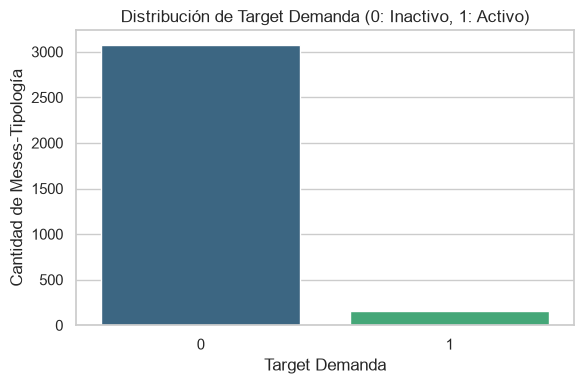

In [83]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="target_demanda",
    hue="target_demanda",
    palette="viridis",
    legend=False
)

plt.title("Distribución de Target Demanda (0: Inactivo, 1: Activo)")
plt.xlabel("Target Demanda")
plt.ylabel("Cantidad de Meses-Tipología")

plt.tight_layout()

plt.savefig(output_dir / "distribucion_target.png", dpi=300)

plt.show()


# Variables demográficas

In [84]:
columns = [
    "hombres",
    "mujeres",
    "ninos_ninas",
    "adolescentes",
    "total_atenciones"
]

df[columns].describe()


,hombres,mujeres,ninos_ninas,adolescentes,total_atenciones
count,3234.000000,3234.000000,3234.000000,3234.000000,3234.000000
mean,0.035869,0.057823,0.047310,0.045764,0.093692
std,0.265468,0.368152,0.340012,0.316192,0.549051
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000
max,6.000000,6.000000,5.000000,6.000000,10.000000


# Estacionalidad mensual

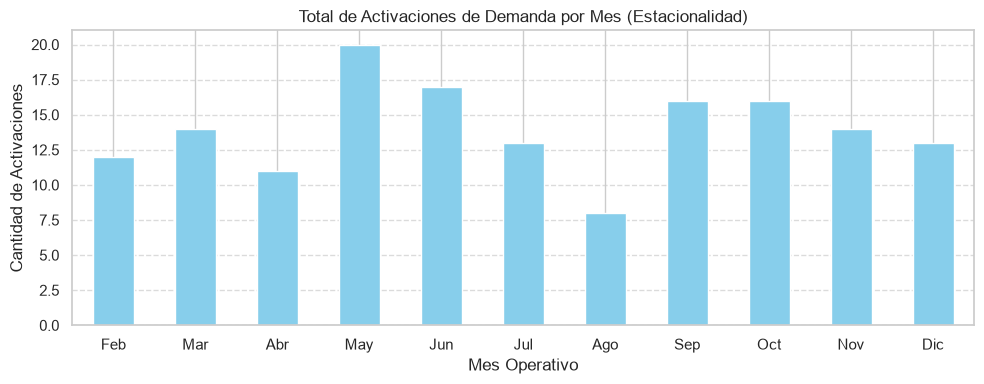

In [85]:
monthly = df.groupby("mes")["target_demanda"].sum()

plt.figure(figsize=(10, 4))

ax = monthly.plot(
    kind="bar",
    color="skyblue"
)

nombres_meses = [
    "Feb", "Mar", "Abr", "May", "Jun",
    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"
]

ax.set_xticklabels(
    nombres_meses[:len(monthly)],
    rotation=0
)

plt.title("Total de Activaciones de Demanda por Mes (Estacionalidad)")
plt.xlabel("Mes Operativo")
plt.ylabel("Cantidad de Activaciones")
plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()

plt.savefig(
    output_dir / "estacionalidad_mensual.png",
    dpi=300
)

plt.show()

# Tipologías más frecuentes

In [86]:
df["tipologia"].value_counts().head(10)


tipologia
Abandono Emocional o Psico-afectivo    33
Abandono Escolar                       33
Abandono NNA                           33
Abandono a Niñas o Niños               33
Abandono de Familia                    33
Abandono de Hogar                      33
Abandono de Mujer Embarazada           33
Aborto                                 33
Aborto Culposo                         33
Aborto Forzado                         33
Name: count, dtype: int64

# Top 10 tipologías

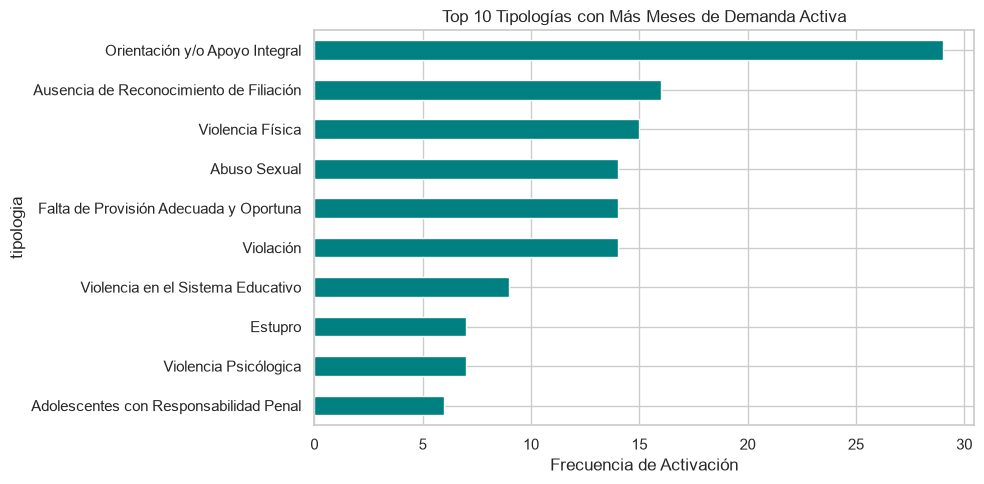

In [87]:
top = (
    df.groupby(
        "tipologia",
        observed=False
    )["target_demanda"]
    .sum()
    .nlargest(10)
)

plt.figure(figsize=(10, 5))

top.plot(
    kind="barh",
    color="teal"
)

plt.gca().invert_yaxis()

plt.title("Top 10 Tipologías con Más Meses de Demanda Activa")
plt.xlabel("Frecuencia de Activación")

plt.tight_layout()

plt.savefig(
    output_dir / "top_10_tipologias.png",
    dpi=300
)

plt.show()


# Distribución de atenciones

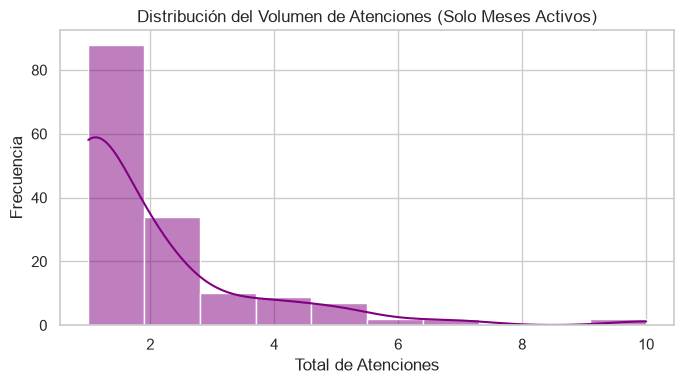

In [88]:
data = df[df["total_atenciones"] > 0]["total_atenciones"]

plt.figure(figsize=(7, 4))

sns.histplot(
    data,
    kde=True,
    bins=10,
    color="purple"
)

plt.title("Distribución del Volumen de Atenciones (Solo Meses Activos)")
plt.xlabel("Total de Atenciones")
plt.ylabel("Frecuencia")

plt.tight_layout()

plt.savefig(
    output_dir / "distribucion_atenciones.png",
    dpi=300
)

plt.show()


# Matriz de correlación

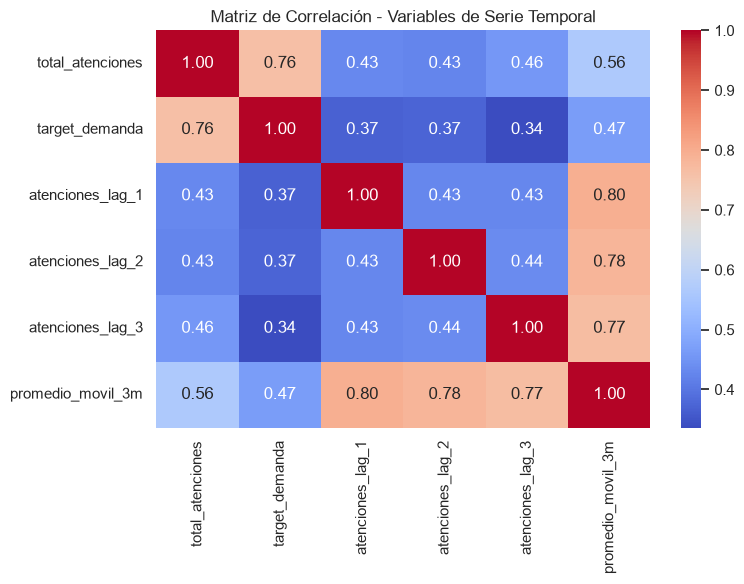

In [89]:
columns = [
    "total_atenciones",
    "target_demanda",
    "atenciones_lag_1",
    "atenciones_lag_2",
    "atenciones_lag_3",
    "promedio_movil_3m"
]

correlation = df[columns].corr()

plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlación - Variables de Serie Temporal")

plt.tight_layout()

plt.savefig(
    output_dir / "correlacion_variables_temporales.png",
    dpi=300
)

plt.show()


# Detección de outliers

In [90]:
q1 = df["total_atenciones"].quantile(0.25)
q3 = df["total_atenciones"].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

outliers = df[df["total_atenciones"] > upper_limit]

print(f"Q1={q1}")
print(f"Q3={q3}")
print(f"IQR={iqr}")
print(f"Límite={upper_limit}")

outliers


Q1=0.0
Q3=0.0
IQR=0.0
Límite=0.0


,gestion,mes,id_tipologia,tipologia,nivel_complejidad,hombres,mujeres,ninos_ninas,adolescentes,total_atenciones,target_demanda,atenciones_lag_1,atenciones_lag_2,atenciones_lag_3,promedio_movil_3m
1,2023,3,1,Asistencia Familiar,Baja,0,1,0,1,1,1,0,0,0,0.0
38,2023,7,2,Conflictos de Guarda,Media,2,0,2,0,2,1,0,0,0,0.0
47,2024,5,2,Conflictos de Guarda,Media,1,1,2,0,2,1,0,0,0,0.0
103,2023,6,4,Extravío,Media,1,0,1,0,1,1,0,0,0,0.0
132,2023,2,5,Imposibilidad de Deberes por Causa Ajena,Media,0,2,0,2,2,1,0,0,0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1382,2025,9,42,Estupro,Alta,0,2,0,2,2,1,0,0,0,0.0
1537,2024,10,47,Proxenetismo,Media,0,1,0,1,1,1,0,0,0,0.0
1977,2025,10,60,Lesiones Graves y Leves,Media,1,0,0,1,1,1,0,0,0,0.0
2138,2025,6,65,Abandono a Niñas o Niños,Media,1,2,3,0,3,1,0,0,0,0.0


# Boxplot de outliers

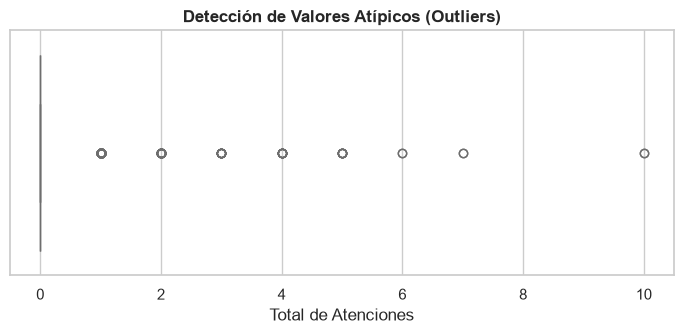

In [91]:
plt.figure(figsize=(7, 3.5))

sns.boxplot(
    x=df["total_atenciones"],
    color="lightcoral"
)

plt.title(
    "Detección de Valores Atípicos (Outliers)",
    fontweight="bold"
)

plt.xlabel("Total de Atenciones")

plt.tight_layout()

plt.savefig(
    output_dir / "boxplot_outliers_atenciones.png",
    dpi=300
)

plt.show()


# Boxplot por complejidad

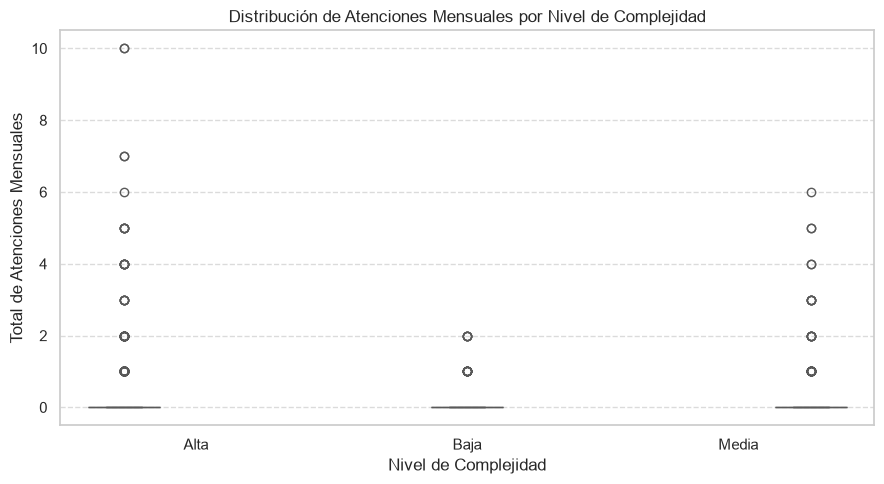

In [92]:
plt.figure(figsize=(9, 5))

sns.boxplot(
    data=df,
    x="nivel_complejidad",
    y="total_atenciones",
    hue="nivel_complejidad",
    palette="Set2",
    legend=False
)

plt.title("Distribución de Atenciones Mensuales por Nivel de Complejidad")

plt.xlabel("Nivel de Complejidad")
plt.ylabel("Total de Atenciones Mensuales")

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.7
)

plt.tight_layout()

plt.savefig(
    output_dir / "anexo_a_boxplot_atipicos.png",
    dpi=300
)

plt.show()


# Grupo etario

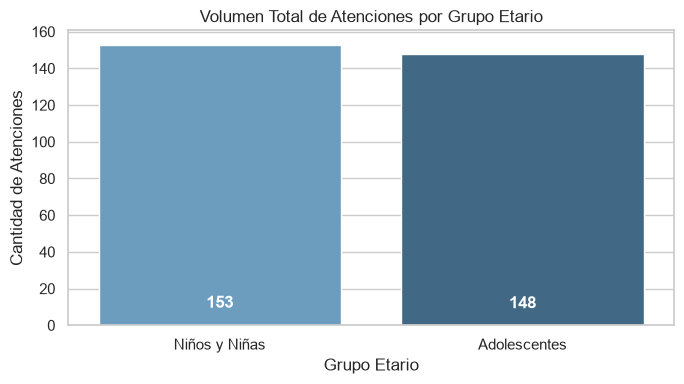

In [93]:
data = (
    df[
        [
            "ninos_ninas",
            "adolescentes"
        ]
    ]
    .sum()
    .reset_index()
)

data.columns = [
    "Grupo Etario",
    "Total Atenciones"
]

data["Grupo Etario"] = data["Grupo Etario"].replace(
    {
        "ninos_ninas": "Niños y Niñas",
        "adolescentes": "Adolescentes"
    }
)

fig, ax = plt.subplots(figsize=(7, 4))

sns.barplot(
    data=data,
    x="Grupo Etario",
    y="Total Atenciones",
    hue="Grupo Etario",
    palette="Blues_d",
    legend=False,
    ax=ax
)

ax.set_title("Volumen Total de Atenciones por Grupo Etario")
ax.set_xlabel("Grupo Etario")
ax.set_ylabel("Cantidad de Atenciones")

for index, row in data.iterrows():
    ax.text(
        index,
        row["Total Atenciones"] * 0.05,
        f"{int(row['Total Atenciones'])}",
        ha="center",
        va="bottom",
        color="white",
        fontweight="bold"
    )

plt.tight_layout()

plt.savefig(
    output_dir / "anexo_a_grupo_etario.png",
    dpi=300
)

plt.show()


# Distribución por sexo

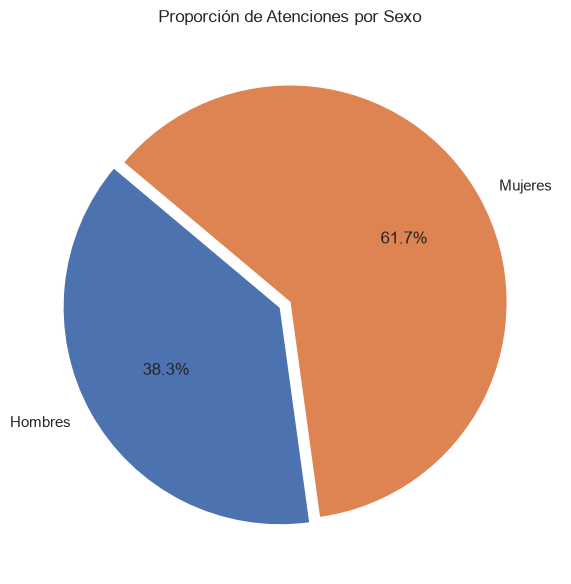

In [94]:
data = df[
    [
        "hombres",
        "mujeres"
    ]
].sum()

plt.figure(figsize=(6, 6))

plt.pie(
    data,
    labels=["Hombres", "Mujeres"],
    autopct="%1.1f%%",
    colors=["#4C72B0", "#DD8452"],
    startangle=140,
    explode=(0.05, 0)
)

plt.title("Proporción de Atenciones por Sexo")

plt.tight_layout()

plt.savefig(
    output_dir / "anexo_a_distribucion_sexo.png",
    dpi=300
)

plt.show()


# Exportar catálogo de tipologías

In [95]:
table = (
    df.groupby(
        ["id_tipologia", "tipologia"],
        observed=True
    )["total_atenciones"]
    .sum()
    .reset_index()
    .sort_values(
        by="total_atenciones",
        ascending=False
    )
)

output_file = output_dir / "tabla_anexo_a_catalogo_completo.csv"

table.to_csv(output_file, index=False)

table.head()


,id_tipologia,tipologia,total_atenciones
37,38,Orientación y/o Apoyo Integral,115
10,11,Violencia en el Sistema Educativo,24
8,9,Violencia Física,23
13,14,Falta de Provisión Adecuada y Oportuna,22
6,7,Ausencia de Reconocimiento de Filiación,21
